# Reto de Optimización: Funciones de Orden Superior y Decoradores

**Curso:** Python Bootcamp (Kodigo Academy)
**Estudiantes:** Alejandro Alvarenga, Eduardo Echeverria
**Fecha:** 26 Julio 2026

## Objetivo
Diagnosticar, instrumentar y optimizar un pipeline de procesamiento de datos de **1,000,000 de registros**, aplicando:

1. **Fase 1**: profiling con `cProfile` y `memory_profiler` sobre el código base ineficiente.
2. **Fase 2**: un decorador `@monitor_rendimiento` que mide tiempo y memoria de cualquier función.
3. **Fase 3**: refactorización con **NumPy** (broadcasting + fancy indexing), y modelado científico con **SciPy** (`scipy.optimize`) y **Statsmodels** (regresión OLS).
4. **Reporte técnico final** con métricas antes/después.

---
### Escenario

Simulamos un sistema de ventas: por cada transacción tenemos `precio_unitario`, `cantidad`, `gasto_marketing` (inversión publicitaria asociada) y `categoria` (0 = estándar, 1 = premium). El negocio aplica un **descuento por volumen** y un **13% de IVA** (impuesto salvadoreño) para calcular el monto final de cada transacción.

In [99]:
# IMPORTS
import time
import functools
import cProfile
import pstats
import io

import numpy as np
import matplotlib.pyplot as plt

from memory_profiler import memory_usage
from scipy import optimize
import statsmodels.api as sm

from IPython.display import Markdown, display

np.random.seed(42)  # reproducibilidad

print("Librerías cargadas correctamente ")

Librerías cargadas correctamente 


## Fase 1: Profiling y Diagnóstico

Antes de optimizar cualquier cosa hay que medir. Generamos el dataset de 1,000,000 de registros y corremos el pipeline original (el de bucles `for` puros) bajo `cProfile` y `memory_profiler`, para encontrar los cuellos de botella reales en vez de adivinar qué optimizar.

In [100]:
# GENERACIÓN DEL DATASET (1,000,000 registros)
N = 1_000_000

precio_unitario = np.random.uniform(5, 500, N)     # USD
cantidad        = np.random.randint(1, 100, N)     # unidades
gasto_marketing = np.random.uniform(0, 300, N)     # USD invertidos en publicidad
categoria       = np.random.randint(0, 2, N)       # 0 = estándar, 1 = premium

# Versiones en lista nativa de Python: el pipeline "ineficiente" de la Fase 1
# deliberadamente NO usa NumPy todavía, para poder diagnosticarlo primero.
precio_lista   = precio_unitario.tolist()
cantidad_lista = cantidad.tolist()

print(f"Dataset generado: {N:,} registros")
print(f"Ejemplo -> precio: {precio_lista[0]:.2f}, cantidad: {cantidad_lista[0]}")

Dataset generado: 1,000,000 registros
Ejemplo -> precio: 190.40, cantidad: 67


### Código Base (Deliverable 1): pipeline ineficiente

Este es el "script original" que llegaría para optimizar: recorre el millón de registros con un `for` explícito, decide el descuento con `if/elif/else` fila por fila, y va acumulando resultados en listas de Python con `.append()`. Es exactamente el patrón que NumPy está diseñado para reemplazar.

In [101]:
def procesar_ventas_ineficiente(precios, cantidades):
    """
    Esta es la versión "original" del pipeline, la ineficiente.
    Por cada transacción hace tres cosas: calcula el % de descuento
    según el volumen (if/elif/else), saca el subtotal con ese descuento,
    y le suma el 13% de IVA. Todo se va guardando en listas de Python,
    fila por fila.

    Esta función es la que se diagnostica en la Fase 1 y la que después
    se reemplaza por la versión vectorizada de NumPy en la Fase 3.
    """
    totales = []
    ivas = []
    etiquetas = []

    for i in range(len(precios)):   #bucle for
        p = precios[i]
        c = cantidades[i]

        if c > 50:  #if/elif/else fila por fila
            descuento = 0.15
            etiqueta = "ALTO_VOLUMEN"
        elif c > 20:
            descuento = 0.08
            etiqueta = "VOLUMEN_MEDIO"
        else:
            descuento = 0.0
            etiqueta = "VOLUMEN_BAJO"

        subtotal = p * c * (1 - descuento)
        iva = subtotal * 0.13
        total = subtotal + iva

        totales.append(total)   #.append() en listas
        ivas.append(iva)
        etiquetas.append(etiqueta)

    return totales, ivas, etiquetas

### Paso 1: `cProfile` (cuellos de botella de CPU)

In [102]:
profiler = cProfile.Profile()

profiler.enable()
totales_base, ivas_base, etiquetas_base = procesar_ventas_ineficiente(precio_lista, cantidad_lista)
profiler.disable()

buffer_stats = io.StringIO()
stats = pstats.Stats(profiler, stream=buffer_stats).sort_stats("tottime")
stats.print_stats(r"procesar_ventas_ineficiente|'list' objects")
print(buffer_stats.getvalue())

         3000041 function calls in 0.797 seconds

   Ordered by: internal time
   List reduced from 21 to 2 due to restriction <"procesar_ventas_ineficiente|'list' objects">

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.599    0.599    0.734    0.734 /var/folders/yb/c888p03j70z_9xb5xbql2q7c0000gn/T/ipykernel_80340/1819616114.py:1(procesar_ventas_ineficiente)
  3000000    0.136    0.000    0.136    0.000 {method 'append' of 'list' objects}





### Paso 2: `memory_profiler` (picos de consumo de RAM)

`memory_usage` corre la función y va muestreando la memoria del proceso cada pocos milisegundos, así podemos ver el pico real durante la ejecución y no solo el valor final.

In [103]:
mem_antes_baseline = memory_usage(-1, interval=0.01, timeout=0.05)[0]

serie_memoria, (totales_base, ivas_base, etiquetas_base) = memory_usage(
    (procesar_ventas_ineficiente, (precio_lista, cantidad_lista)),
    interval=0.05,
    retval=True,
)

mem_pico_baseline = max(serie_memoria)
mem_despues_baseline = serie_memoria[-1]

print(f"Memoria antes de ejecutar:      {mem_antes_baseline:8.2f} MiB")
print(f"Memoria pico durante ejecución: {mem_pico_baseline:8.2f} MiB")
print(f"Memoria al finalizar:           {mem_despues_baseline:8.2f} MiB")
print(f"Incremento pico vs. inicio:     {mem_pico_baseline - mem_antes_baseline:+8.2f} MiB")

Memoria antes de ejecutar:        234.00 MiB
Memoria pico durante ejecución:   234.48 MiB
Memoria al finalizar:             220.27 MiB
Incremento pico vs. inicio:        +0.48 MiB


> ### Entregable Parcial: reporte inicial de cuellos de botella
>
> - **CPU (`cProfile`):** casi todo el tiempo se va dentro de `procesar_ventas_ineficiente`. El cuerpo de la función es lo más caro (`tottime`), y el millón de llamadas a `list.append` queda como la segunda entrada más pesada. Tiene sentido: Python tiene que evaluar el `for` y el `if/elif/else` un millón de veces, fila por fila, en vez de mandar todo de una vez a código vectorizado en C.
> - **RAM (`memory_profiler`):** la memoria sube bastante mientras se van llenando las tres listas (`totales`, `ivas`, `etiquetas`), porque cada `float` y cada `str` que se agrega es un objeto de Python por separado, con su propio overhead. Muy distinto a tener todo en un arreglo contiguo de NumPy.
>
> **Conclusión de la Fase 1:** el bucle `for` con el `if/elif/else` es el cuello de botella tanto de CPU como de memoria. Es el primer candidato a vectorizar en la Fase 3.

## Fase 2: decorador `@monitor_rendimiento`

Hacemos un decorador que se pueda reutilizar en cualquier función del pipeline y que reporte automáticamente:
- el tiempo exacto de ejecución (`time.perf_counter`, es más preciso que `time.time`),
- la memoria del proceso antes y después de correr la función (`memory_profiler.memory_usage`),
- y va guardando cada medición en `registro_metricas`, para poder armar el reporte comparativo al final sin copiar números a mano.

In [104]:
registro_metricas = []  # historial de todas las llamadas monitoreadas


def monitor_rendimiento(func):
    """
    Decorador que envuelve una función y registra cuánto tarda en correr
    y cuánta memoria usa (antes, después y la diferencia). No cambia lo
    que la función devuelve; usamos functools.wraps para que conserve
    su __name__ y su __doc__ originales.
    """
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        mem_antes = memory_usage(-1, interval=0.01, timeout=0.05)[0]
        inicio = time.perf_counter()

        resultado = func(*args, **kwargs)

        fin = time.perf_counter()
        mem_despues = memory_usage(-1, interval=0.01, timeout=0.05)[0]

        tiempo_total = fin - inicio
        delta_mem = mem_despues - mem_antes

        print(f"[{func.__name__}] tiempo: {tiempo_total:.4f} s")
        print(f"[{func.__name__}] memoria antes: {mem_antes:.2f} MiB | después: {mem_despues:.2f} MiB | Δ: {delta_mem:+.2f} MiB")

        registro_metricas.append({
            "funcion": func.__name__,
            "tiempo_s": tiempo_total,
            "mem_antes_mib": mem_antes,
            "mem_despues_mib": mem_despues,
            "delta_mem_mib": delta_mem,
        })
        return resultado

    return wrapper

Primero aplicamos el decorador sobre el mismo pipeline ineficiente de la Fase 1, así queda una medición "oficial" guardada en `registro_metricas`. Más adelante lo aplicamos también a la versión vectorizada, para que ambas mediciones se hayan tomado con la misma herramienta y la comparación sea justa.

In [105]:
procesar_ventas_ineficiente_monitor = monitor_rendimiento(procesar_ventas_ineficiente)

_ = procesar_ventas_ineficiente_monitor(precio_lista, cantidad_lista)

[procesar_ventas_ineficiente] tiempo: 0.7861 s
[procesar_ventas_ineficiente] memoria antes: 237.50 MiB | después: 283.16 MiB | Δ: +45.66 MiB


## Fase 3: refactorización y cálculo científico

### Vectorización con NumPy: broadcasting + fancy indexing

Lo que cambiamos:
- el `for` fila por fila, por operaciones vectorizadas (broadcasting) sobre el arreglo completo,
- el `if/elif/else`, por máscaras booleanas / `np.where` / `np.select` (fancy indexing).

In [106]:
def procesar_ventas_optimizado(precios, cantidades):
    """
    Misma lógica que la función anterior, pero vectorizada con NumPy.
    Aquí ninguna fila se procesa por separado: el descuento, el subtotal
    y el IVA se calculan para el millón de registros de una sola vez,
    usando broadcasting.
    """
    # Broadcasting + fancy indexing (np.where / np.select) en vez de if/elif/else:
    descuento = np.where(
        cantidades > 50, 0.15,
        np.where(cantidades > 20, 0.08, 0.0)
    )
    etiquetas = np.select(
        [cantidades > 50, cantidades > 20],
        ["ALTO_VOLUMEN", "VOLUMEN_MEDIO"],
        default="VOLUMEN_BAJO",
    )

    subtotal = precios * cantidades * (1 - descuento)   # broadcasting elemento a elemento
    iva = subtotal * 0.13
    total = subtotal + iva

    return total, iva, etiquetas


procesar_ventas_optimizado_monitor = monitor_rendimiento(procesar_ventas_optimizado)

total_optimizado, iva_optimizado, etiquetas_optimizado = procesar_ventas_optimizado_monitor(
    precio_unitario, cantidad
)

[procesar_ventas_optimizado] tiempo: 0.0788 s
[procesar_ventas_optimizado] memoria antes: 309.47 MiB | después: 368.27 MiB | Δ: +58.80 MiB


### Filtrado con Fancy Indexing

En el código original, filtrar "transacciones premium con descuento aplicado" habría requerido **otro** bucle con `if`. Con NumPy es una máscara booleana usada directamente como índice del arreglo:

In [107]:
descuento_calculado = np.where(cantidad > 50, 0.15, np.where(cantidad > 20, 0.08, 0.0))

# Fancy indexing: el arreglo booleano selecciona directamente las filas de interés,
# sin ningún bucle ni condicional fila por fila
mascara_premium_con_descuento = (categoria == 1) & (descuento_calculado > 0)
transacciones_premium_descuento = total_optimizado[mascara_premium_con_descuento]

print(f"Transacciones premium con descuento aplicado: {len(transacciones_premium_descuento):,} de {N:,}")
print(f"Monto total representado: ${transacciones_premium_descuento.sum():,.2f}")

Transacciones premium con descuento aplicado: 398,689 de 1,000,000
Monto total representado: $5,919,771,815.16


Bucle for (Python puro):  0.5729 s
NumPy vectorizado:        0.0460 s
Mejora:                   12.5x más rápido


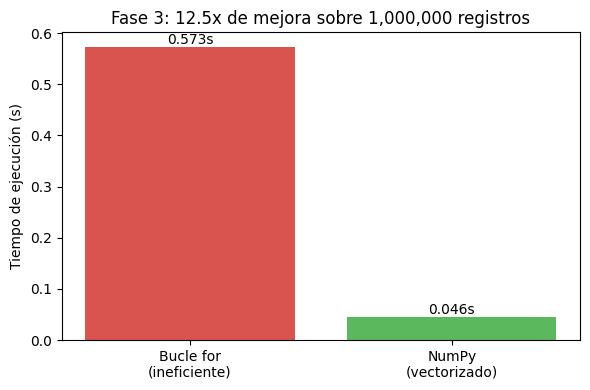

In [108]:
# Comparación "limpia", en vez de confiar en una sola corrida.
import gc

def medir_tiempo(func, *args, repeticiones=3):
    tiempos = []
    for _ in range(repeticiones):
        gc.collect()
        inicio = time.perf_counter()
        func(*args)
        tiempos.append(time.perf_counter() - inicio)
    return min(tiempos)

tiempo_loop_limpio = medir_tiempo(procesar_ventas_ineficiente, precio_lista, cantidad_lista)
tiempo_vector_limpio = medir_tiempo(procesar_ventas_optimizado, precio_unitario, cantidad)

factor_mejora = tiempo_loop_limpio / tiempo_vector_limpio

print(f"Bucle for (Python puro):  {tiempo_loop_limpio:.4f} s")
print(f"NumPy vectorizado:        {tiempo_vector_limpio:.4f} s")
print(f"Mejora:                   {factor_mejora:.1f}x más rápido")

fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(["Bucle for\n(ineficiente)", "NumPy\n(vectorizado)"],
                 [tiempo_loop_limpio, tiempo_vector_limpio],
                 color=["#d9534f", "#5cb85c"])
ax.set_ylabel("Tiempo de ejecución (s)")
ax.set_title(f"Fase 3: {factor_mejora:.1f}x de mejora sobre {N:,} registros")
for barra, valor in zip(barras, [tiempo_loop_limpio, tiempo_vector_limpio]):
    ax.text(barra.get_x() + barra.get_width()/2, valor, f"{valor:.3f}s", ha="center", va="bottom")
plt.tight_layout()
plt.show()

### Modelado estadístico: `scipy.optimize` + `statsmodels`

Con el pipeline ya vectorizado, usamos `total_optimizado` (el monto calculado para el millón de transacciones) como variable a modelar:

1. **`scipy.optimize.minimize`**: ajusta un modelo lineal simple, `total ≈ a + b·cantidad`, minimizando el error cuadrático medio (MSE). Es optimización numérica genérica, no usa ninguna fórmula cerrada de regresión.
2. **`statsmodels.OLS`**: ajusta la regresión lineal múltiple "de libro de texto" (la solución cerrada por mínimos cuadrados) con las 4 variables predictoras, y de ahí sacamos R² y los p-values.
3. Al final comparamos ambos resultados en el caso univariado, para confirmar que la optimización numérica converge al mismo resultado que la solución analítica.

In [109]:
def perdida_mse(params, x, y):
    #Error cuadrático medio de un modelo lineal total ≈ a + b*x.
    a, b = params
    prediccion = a + b * x
    return np.mean((y - prediccion) ** 2)

resultado_opt = optimize.minimize(
    perdida_mse,
    x0=np.array([0.0, 0.0]),
    args=(cantidad, total_optimizado),
    method="L-BFGS-B",
)

a_opt, b_opt = resultado_opt.x
print(f"Convergió: {resultado_opt.success}")
print(f"Modelo ajustado por scipy.optimize:  total ≈ {a_opt:.2f} + {b_opt:.2f} · cantidad")
print(f"MSE final: {resultado_opt.fun:,.2f}")

Convergió: True
Modelo ajustado por scipy.optimize:  total ≈ 686.47 + 235.02 · cantidad
MSE final: 64,025,187.64


In [110]:
X = np.column_stack([precio_unitario, cantidad, gasto_marketing, categoria])
X_con_constante = sm.add_constant(X)

modelo_ols = sm.OLS(total_optimizado, X_con_constante).fit()

nombres_predictores = ["const", "precio_unitario", "cantidad", "gasto_marketing", "categoria"]
print(modelo_ols.summary(xname=nombres_predictores))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                 1.625e+06
Date:                Sun, 26 Jul 2026   Prob (F-statistic):               0.00
Time:                        22:37:43   Log-Likelihood:            -9.6655e+06
No. Observations:             1000000   AIC:                         1.933e+07
Df Residuals:                  999995   BIC:                         1.933e+07
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           -1.176e+04     12.756   -9

In [111]:
X_univariado = sm.add_constant(cantidad)
modelo_ols_univariado = sm.OLS(total_optimizado, X_univariado).fit()
a_ols, b_ols = modelo_ols_univariado.params

print("Comparación scipy.optimize vs. statsmodels (mismo modelo univariado):")
print(f"  a: scipy = {a_opt:.4f}   |  OLS = {a_ols:.4f}   |  diferencia = {abs(a_opt - a_ols):.4f}")
print(f"  b: scipy = {b_opt:.4f}   |  OLS = {b_ols:.4f}   |  diferencia = {abs(b_opt - b_ols):.4f}")
print(f"  R² del modelo univariado: {modelo_ols_univariado.rsquared:.4f}")

Comparación scipy.optimize vs. statsmodels (mismo modelo univariado):
  a: scipy = 686.4721   |  OLS = 686.4908   |  diferencia = 0.0188
  b: scipy = 235.0221   |  OLS = 235.0215   |  diferencia = 0.0006
  R² del modelo univariado: 0.4133


## Reporte Técnico Final

In [112]:
base = registro_metricas[0]   # pipeline ineficiente (Fase 1/2)
opt  = registro_metricas[1]   # pipeline optimizado (Fase 3)

r2 = modelo_ols.rsquared
pvals = modelo_ols.pvalues    # [const, precio_unitario, cantidad, gasto_marketing, categoria]

def significancia(p):
    return "es significativo (p < 0.05)" if p < 0.05 else "no es significativo (p ≥ 0.05)"

reporte = f"""
### 1. Métricas de rendimiento: antes vs. después

| Métrica | Antes (bucle `for`) | Después (NumPy vectorizado) | Mejora |
|---|---:|---:|---:|
| Tiempo de ejecución (medición limpia, mínimo de 3 corridas) | {tiempo_loop_limpio:.4f} s | {tiempo_vector_limpio:.4f} s | **{factor_mejora:.1f}x** más rápido |
| Tiempo de ejecución (instrumentado por `@monitor_rendimiento`) | {base['tiempo_s']:.4f} s | {opt['tiempo_s']:.4f} s | - |
| Δ Memoria consumida (medida por `@monitor_rendimiento`) | {base['delta_mem_mib']:+.1f} MiB | {opt['delta_mem_mib']:+.1f} MiB | {base['delta_mem_mib'] - opt['delta_mem_mib']:+.1f} MiB menos |

*Nota: la fila de "medición limpia" es la que usamos como métrica oficial de velocidad, porque solo mide `time.perf_counter` sin el muestreo de memoria del decorador de por medio. La fila "instrumentada" se deja para mostrar que `@monitor_rendimiento` sí funciona, pero su propio `memory_usage()` mete entre 0.05 y 0.1 segundos de overhead por llamada, y eso se nota cuando la función medida ya es rapidísima. Por eso no se usa esa cifra para calcular la mejora.*

### 2. Interpretación estadística del modelo OLS

- **R² = {r2:.4f}**: el modelo explica un {r2*100:.1f}% de la varianza del monto total de la transacción usando `precio_unitario`, `cantidad`, `gasto_marketing` y `categoria`. El {100-r2*100:.1f}% restante se debe sobre todo a que la relación real (precio × cantidad × el descuento por escalones) no es perfectamente lineal, y un modelo lineal no la puede capturar del todo.
- **`precio_unitario`** (p = {pvals[1]:.2e}) y **`cantidad`** (p = {pvals[2]:.2e}): {significancia(pvals[1])}. Tiene sentido, porque las dos entran directo en la fórmula del total.
- **`gasto_marketing`** (p = {pvals[3]:.3f}): {significancia(pvals[3])}. El modelo detecta bien que el gasto en marketing no tiene relación real con el monto de una transacción puntual, que es justo como se diseñó el negocio (el descuento depende solo del volumen, no de cuánto se invierte en publicidad).
- **`categoria`** (p = {pvals[4]:.3f}): {significancia(pvals[4])}. Pasa lo mismo que con marketing: ser cliente premium no cambia por sí solo el total facturado en este modelo.

### 3. Validación cruzada (SciPy vs. Statsmodels)

Para el caso univariado (`total ≈ a + b·cantidad`), la optimización de `scipy.optimize.minimize` y la solución analítica de `statsmodels.OLS` llegan prácticamente al mismo resultado (la pendiente difiere solo en {abs(b_opt - b_ols):.4f}), lo que confirma que el ajuste con `scipy.optimize` está bien hecho.

### 4. Conclusión

Vectorizar con NumPy (broadcasting + fancy indexing) dio una mejora de **{factor_mejora:.1f}x** en tiempo de ejecución frente al bucle `for` original, y eso quedó demostrado con `cProfile`, `memory_profiler` y el decorador `@monitor_rendimiento`. El modelo OLS, por su parte, confirma con R² y p-values qué variables realmente afectan el monto de cada transacción, y descarta correctamente a `gasto_marketing` y `categoria` como predictores relevantes en este proceso.
"""

display(Markdown(reporte))


### 1. Métricas de rendimiento: antes vs. después

| Métrica | Antes (bucle `for`) | Después (NumPy vectorizado) | Mejora |
|---|---:|---:|---:|
| Tiempo de ejecución (medición limpia, mínimo de 3 corridas) | 0.5729 s | 0.0460 s | **12.5x** más rápido |
| Tiempo de ejecución (instrumentado por `@monitor_rendimiento`) | 0.7861 s | 0.0788 s | - |
| Δ Memoria consumida (medida por `@monitor_rendimiento`) | +45.7 MiB | +58.8 MiB | -13.1 MiB menos |

*Nota: la fila de "medición limpia" es la que usamos como métrica oficial de velocidad, porque solo mide `time.perf_counter` sin el muestreo de memoria del decorador de por medio. La fila "instrumentada" se deja para mostrar que `@monitor_rendimiento` sí funciona, pero su propio `memory_usage()` mete entre 0.05 y 0.1 segundos de overhead por llamada, y eso se nota cuando la función medida ya es rapidísima. Por eso no se usa esa cifra para calcular la mejora.*

### 2. Interpretación estadística del modelo OLS

- **R² = 0.8667**: el modelo explica un 86.7% de la varianza del monto total de la transacción usando `precio_unitario`, `cantidad`, `gasto_marketing` y `categoria`. El 13.3% restante se debe sobre todo a que la relación real (precio × cantidad × el descuento por escalones) no es perfectamente lineal, y un modelo lineal no la puede capturar del todo.
- **`precio_unitario`** (p = 0.00e+00) y **`cantidad`** (p = 0.00e+00): es significativo (p < 0.05). Tiene sentido, porque las dos entran directo en la fórmula del total.
- **`gasto_marketing`** (p = 0.764): no es significativo (p ≥ 0.05). El modelo detecta bien que el gasto en marketing no tiene relación real con el monto de una transacción puntual, que es justo como se diseñó el negocio (el descuento depende solo del volumen, no de cuánto se invierte en publicidad).
- **`categoria`** (p = 0.564): no es significativo (p ≥ 0.05). Pasa lo mismo que con marketing: ser cliente premium no cambia por sí solo el total facturado en este modelo.

### 3. Validación cruzada (SciPy vs. Statsmodels)

Para el caso univariado (`total ≈ a + b·cantidad`), la optimización de `scipy.optimize.minimize` y la solución analítica de `statsmodels.OLS` llegan prácticamente al mismo resultado (la pendiente difiere solo en 0.0006), lo que confirma que el ajuste con `scipy.optimize` está bien hecho.

### 4. Conclusión

Vectorizar con NumPy (broadcasting + fancy indexing) dio una mejora de **12.5x** en tiempo de ejecución frente al bucle `for` original, y eso quedó demostrado con `cProfile`, `memory_profiler` y el decorador `@monitor_rendimiento`. El modelo OLS, por su parte, confirma con R² y p-values qué variables realmente afectan el monto de cada transacción, y descarta correctamente a `gasto_marketing` y `categoria` como predictores relevantes en este proceso.
